# Real-data validation: evaluation vs. real_skip

Compares the model's own computed `evaluation` (Algorithm A4 / Design 5, run over real
Spotify sessions via `run_real_session`) against `real_skip`, Mark's derived binary skip
coding, for the sessions in `results/data/real_sessions_sample_qualifying_timeseries.csv`
(5,000 sessions sampled from 5 files, filtered to session_length==20 with a repeat at
position >= 11 and a gap >= 3 from its first play -- see `run_simulation.qualifying_sessions`).

This is a VALIDATION comparison only -- `real_skip` was never learned into the model's
memory or used in computing `evaluation`; it rides along purely for this comparison.

## Parameters

In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from run_simulation import drop_first_evaluable_trial

RESULTS_PATH = "../results/data/real_sessions_sample_qualifying_timeseries.csv"
NUM_BINS = 12          # quantile bins of `evaluation` for the skip-rate curve below

## Load and summarize

Drops the ~1.7% of rows where `real_skip` is undefined (neither skip_1/2/3 nor not_skipped
was true -- see `add_real_skip`'s docstring), and each session's first evaluable trial
(confirmed with Mark, 2026-08-28): on a fresh model, Algorithm A4's running time-averaged
aesthetic basis has only one data point on its first update, forcing `aesthetic_basis == r`
exactly and `evaluation == 0` deterministically -- unrelated to real skip behavior, and since
every session gets its own fresh model, this hits every single session once (confirmed
empirically: 100% correspondence between evaluation==0 rows and each session's first
evaluable trial). See `run_simulation.drop_first_evaluable_trial`.

In [2]:
df = pd.read_csv(RESULTS_PATH)
d = df.dropna(subset=["real_skip", "evaluation"]).copy()
print(f"{len(d)} / {len(df)} rows usable (excluding undefined real_skip)")

d = drop_first_evaluable_trial(d)
print(f"{len(d)} rows after also excluding each session's first evaluable trial")

pearson_r = d["real_skip"].corr(d["evaluation"])
spearman_r = d["evaluation"].rank().corr(d["real_skip"].rank())
print(f"Pearson/point-biserial r: {pearson_r:.4f}")
print(f"Spearman (rank) r:        {spearman_r:.4f}")

26714 / 27159 rows usable (excluding undefined real_skip)
22476 rows after also excluding each session's first evaluable trial
Pearson/point-biserial r: -0.0225
Spearman (rank) r:        -0.0593


## Binned skip rate vs. evaluation

A raw scatter isn't informative here since `real_skip` is binary -- instead, `evaluation` is
split into `NUM_BINS` equal-count (quantile) bins, and the actual skip rate (with a 95%
Wald CI) is computed within each bin. Quantile bins are used rather than equal-width ones
because `evaluation`'s distribution is heavy-tailed (a handful of large-magnitude outliers
would otherwise leave most bins nearly empty). The bottom panel shows where those bin edges
actually fall against the raw distribution, since equal-count bins can span very unequal
`evaluation` ranges under a skewed distribution like this one.

In [3]:
d["eval_bin"] = pd.qcut(d["evaluation"], q=NUM_BINS, duplicates="drop")

binned = d.groupby("eval_bin", observed=True).agg(
    bin_mean_evaluation=("evaluation", "mean"),
    skip_rate=("real_skip", "mean"),
    n=("real_skip", "size"),
).reset_index()
binned["se"] = np.sqrt(binned["skip_rate"] * (1 - binned["skip_rate"]) / binned["n"])
binned["ci95"] = 1.96 * binned["se"]
binned

,eval_bin,bin_mean_evaluation,skip_rate,n,se,ci95
0,"(-103.465, -6.734]",-11.951165,0.552056,1873,0.011490,0.022521
1,"(-6.734, -4.1]",-5.283898,0.571276,1873,0.011435,0.022413
2,"(-4.1, -2.6]",-3.275162,0.575013,1873,0.011422,0.022388
3,"(-2.6, -1.553]",-2.045791,0.567539,1873,0.011447,0.022437
4,"(-1.553, -0.77]",-1.146625,0.538708,1873,0.011518,0.022576
5,"(-0.77, -0.177]",-0.461214,0.548318,1873,0.011499,0.022538
6,"(-0.177, 0.214]",0.038327,0.514682,1873,0.011548,0.022634
7,"(0.214, 0.496]",0.358812,0.513081,1873,0.011549,0.022636
8,"(0.496, 0.71]",0.606480,0.492792,1873,0.011552,0.022642
9,"(0.71, 0.868]",0.794766,0.498131,1873,0.011553,0.022644


/var/folders/87/p5brvyr10fv6zn9gv1q2ct380000gp/T/ipykernel_2224/901315217.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


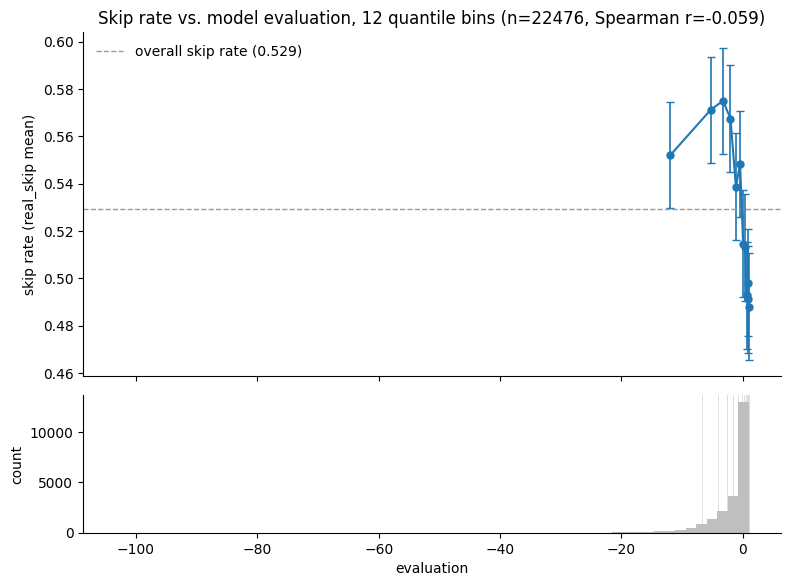

In [4]:
fig, (ax_rate, ax_hist) = plt.subplots(
    2, 1, figsize=(9, 6.5), sharex=True, height_ratios=[2.5, 1],
    gridspec_kw={"hspace": 0.08})

ax_rate.errorbar(binned["bin_mean_evaluation"], binned["skip_rate"], yerr=binned["ci95"],
                  fmt="o-", color="tab:blue", ecolor="tab:blue", elinewidth=1.2,
                  capsize=3, markersize=5, linewidth=1.5)
overall_rate = d["real_skip"].mean()
ax_rate.axhline(overall_rate, color="0.6", linewidth=1, linestyle="--",
                 label=f"overall skip rate ({overall_rate:.3f})")
ax_rate.set_ylabel("skip rate (real_skip mean)")
ax_rate.set_title(f"Skip rate vs. model evaluation, {NUM_BINS} quantile bins "
                   f"(n={len(d)}, Spearman r={spearman_r:.3f})")
ax_rate.legend(frameon=False, loc="best")
ax_rate.spines[["top", "right"]].set_visible(False)

ax_hist.hist(d["evaluation"], bins=60, color="0.75", edgecolor="none")
for edge in pd.IntervalIndex(d["eval_bin"].cat.categories).right[:-1]:
    ax_hist.axvline(edge, color="0.85", linewidth=0.6, zorder=0)
ax_hist.set_xlabel("evaluation")
ax_hist.set_ylabel("count")
ax_hist.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## Zoomed view (excluding the extreme tail)

The histogram above shows most mass sits in a narrow band around 0 with a long negative
tail. This repeats the same binned view restricted to the 5th-95th percentile range of
`evaluation`, so the bulk of the data isn't visually dominated by a handful of outliers.

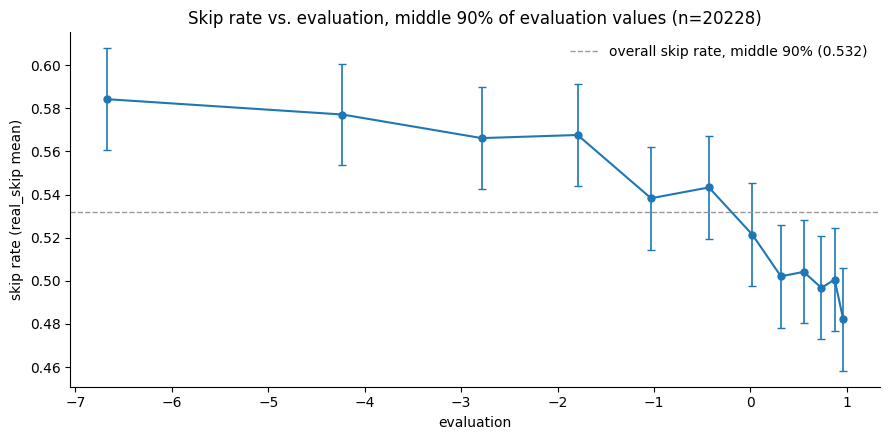

In [5]:
lo, hi = d["evaluation"].quantile([0.05, 0.95])
d_mid = d[(d["evaluation"] >= lo) & (d["evaluation"] <= hi)].copy()
d_mid["eval_bin"] = pd.qcut(d_mid["evaluation"], q=NUM_BINS, duplicates="drop")

binned_mid = d_mid.groupby("eval_bin", observed=True).agg(
    bin_mean_evaluation=("evaluation", "mean"),
    skip_rate=("real_skip", "mean"),
    n=("real_skip", "size"),
).reset_index()
binned_mid["ci95"] = 1.96 * np.sqrt(binned_mid["skip_rate"] * (1 - binned_mid["skip_rate"]) / binned_mid["n"])

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.errorbar(binned_mid["bin_mean_evaluation"], binned_mid["skip_rate"], yerr=binned_mid["ci95"],
            fmt="o-", color="tab:blue", ecolor="tab:blue", elinewidth=1.2,
            capsize=3, markersize=5, linewidth=1.5)
ax.axhline(d_mid["real_skip"].mean(), color="0.6", linewidth=1, linestyle="--",
           label=f"overall skip rate, middle 90% ({d_mid['real_skip'].mean():.3f})")
ax.set_xlabel("evaluation")
ax.set_ylabel("skip rate (real_skip mean)")
ax.set_title(f"Skip rate vs. evaluation, middle 90% of evaluation values (n={len(d_mid)})")
ax.legend(frameon=False, loc="best")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Confound check: is this really about evaluation, or just session position?

Mark spotted a real confound (2026-08-28): `qualifying_sessions` requires the repeat at
`session_position >= 11`, so every evaluated row above is, by construction, from late in a
session. Any evaluation-vs-real_skip relationship could just be a generic "skip rate varies
with position in the session" effect, unrelated to the model's memory dynamics at all.

To check, we compare skip rate by `session_position` in two populations:
- **Evaluated rows** (from above, after dropping each session's first-evaluable-trial
  artifact) -- these only exist at position >= 11 by construction.
- **A no-repeat control**: session_length==20 sessions with NO repeated track at all, so no
  evaluation is even possible -- every one of their 20 positions is included. This is the
  "pure position effect" baseline, uncontaminated by anything repeat- or memory-related.

If the two curves look similar over the overlapping 11-20 range, the earlier result is likely
just tracking position. If the control is flat while the evaluated-rows curve still trends,
that argues the earlier result reflects something beyond mere position.

In [6]:
NO_REPEAT_PATH = "../results/data/no_repeat_sessions_sample.csv" 

In [7]:
control = pd.read_csv(NO_REPEAT_PATH)
control = control.dropna(subset=["real_skip"])
print(f"{len(control)} control rows, {control['session_id'].nunique()} no-repeat sessions")

def skip_rate_by_position(frame):
    g = frame.groupby("session_position").agg(
        skip_rate=("real_skip", "mean"), n=("real_skip", "size")).reset_index()
    g["ci95"] = 1.96 * np.sqrt(g["skip_rate"] * (1 - g["skip_rate"]) / g["n"])
    return g

control_by_pos = skip_rate_by_position(control)
evaluated_by_pos = skip_rate_by_position(d.rename(columns={"session_position": "session_position"}))
control_by_pos.head(3), evaluated_by_pos.head(3)

163619 control rows, 8307 no-repeat sessions


(   session_position  skip_rate     n      ci95
 0                 1   0.389263  8028  0.010666
 1                 2   0.452918  8156  0.010803
 2                 3   0.492896  8164  0.010845,
    session_position  skip_rate    n      ci95
 0                 3   0.333333   69  0.111231
 1                 4   0.386617  269  0.058195
 2                 5   0.456290  469  0.045079)

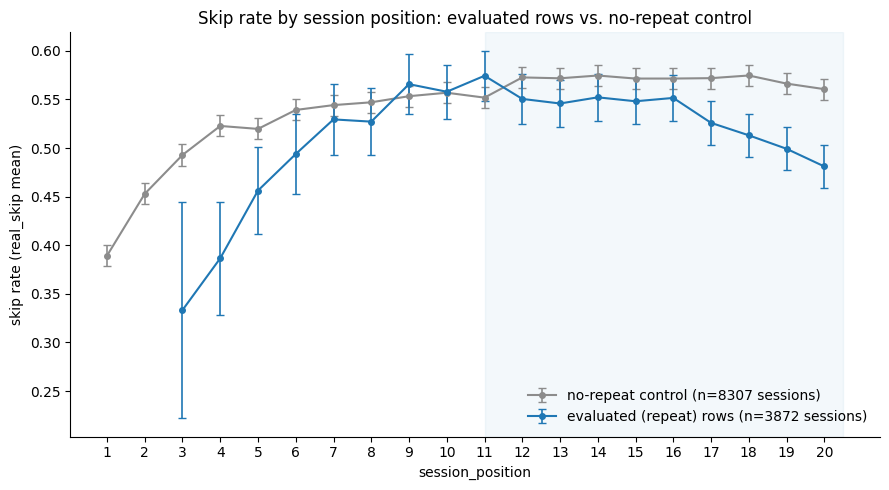

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(control_by_pos["session_position"], control_by_pos["skip_rate"],
            yerr=control_by_pos["ci95"], fmt="o-", color="0.55", ecolor="0.55",
            elinewidth=1.2, capsize=3, markersize=4, linewidth=1.5,
            label=f"no-repeat control (n={control['session_id'].nunique()} sessions)")
ax.errorbar(evaluated_by_pos["session_position"], evaluated_by_pos["skip_rate"],
            yerr=evaluated_by_pos["ci95"], fmt="o-", color="tab:blue", ecolor="tab:blue",
            elinewidth=1.2, capsize=3, markersize=4, linewidth=1.5,
            label=f"evaluated (repeat) rows (n={d['session_id'].nunique()} sessions)")

ax.axvspan(11, 20.5, color="tab:blue", alpha=0.05, zorder=0)
ax.set_xlabel("session_position")
ax.set_ylabel("skip rate (real_skip mean)")
ax.set_xticks(range(1, 21))
ax.set_title("Skip rate by session position: evaluated rows vs. no-repeat control")
ax.legend(frameon=False, loc="best")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Replicating graphs 1 & 2 for the no-repeat condition

No-repeat sessions have no `evaluation` at all -- Algorithm A4 only produces a value on a
repeat exposure, and these sessions have none by construction. So the same binned-skip-rate
treatment from the two charts above is reproduced here using `session_position` as the x-axis
in place of `evaluation` (the same substitute variable already used in the confound-check
section), for a direct visual comparison against those two shapes.

In [9]:
control["position_bin"] = pd.qcut(control["session_position"], q=NUM_BINS, duplicates="drop")

binned_control = control.groupby("position_bin", observed=True).agg(
    bin_mean_position=("session_position", "mean"),
    skip_rate=("real_skip", "mean"),
    n=("real_skip", "size"),
).reset_index()
binned_control["ci95"] = 1.96 * np.sqrt(
    binned_control["skip_rate"] * (1 - binned_control["skip_rate"]) / binned_control["n"])
binned_control

,position_bin,bin_mean_position,skip_rate,n,ci95
0,"(0.999, 2.0]",1.503955,0.421342,16184,0.007607
1,"(2.0, 4.0]",3.500306,0.507834,16338,0.007666
2,"(4.0, 6.0]",5.499450,0.529441,16372,0.007646
3,"(6.0, 7.0]",7.000000,0.544189,8192,0.010785
4,"(7.0, 9.0]",8.500244,0.550219,16408,0.007612
5,"(9.0, 11.0]",10.499022,0.554408,16358,0.007617
6,"(11.0, 12.0]",12.000000,0.572684,8193,0.010712
7,"(12.0, 14.0]",13.499878,0.573199,16380,0.007575
8,"(14.0, 16.0]",15.499512,0.571507,16404,0.007573
9,"(16.0, 17.0]",17.000000,0.571917,8197,0.010712


/var/folders/87/p5brvyr10fv6zn9gv1q2ct380000gp/T/ipykernel_2224/455932545.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


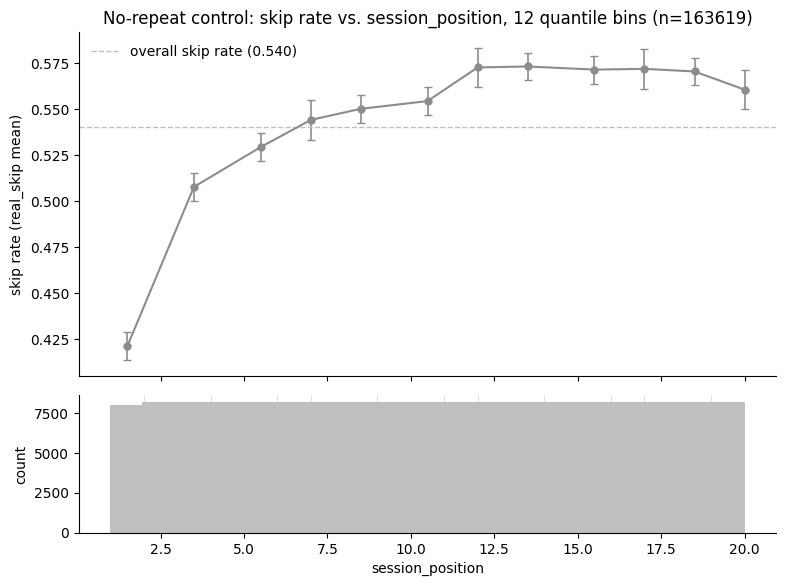

In [10]:
fig, (ax_rate, ax_hist) = plt.subplots(
    2, 1, figsize=(9, 6.5), sharex=True, height_ratios=[2.5, 1],
    gridspec_kw={"hspace": 0.08})

ax_rate.errorbar(binned_control["bin_mean_position"], binned_control["skip_rate"],
                  yerr=binned_control["ci95"], fmt="o-", color="0.55", ecolor="0.55",
                  elinewidth=1.2, capsize=3, markersize=5, linewidth=1.5)
overall_rate_control = control["real_skip"].mean()
ax_rate.axhline(overall_rate_control, color="0.75", linewidth=1, linestyle="--",
                 label=f"overall skip rate ({overall_rate_control:.3f})")
ax_rate.set_ylabel("skip rate (real_skip mean)")
ax_rate.set_title(f"No-repeat control: skip rate vs. session_position, {NUM_BINS} quantile bins "
                   f"(n={len(control)})")
ax_rate.legend(frameon=False, loc="best")
ax_rate.spines[["top", "right"]].set_visible(False)

ax_hist.hist(control["session_position"], bins=20, color="0.75", edgecolor="none")
for edge in pd.IntervalIndex(control["position_bin"].cat.categories).right[:-1]:
    ax_hist.axvline(edge, color="0.85", linewidth=0.6, zorder=0)
ax_hist.set_xlabel("session_position")
ax_hist.set_ylabel("count")
ax_hist.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

### Zoomed view (middle 90% of session_position)

Reproduced for structural symmetry with graph 2 above, though `session_position` has no
heavy tail the way `evaluation` did -- this mostly just trims the very first/last position(s).

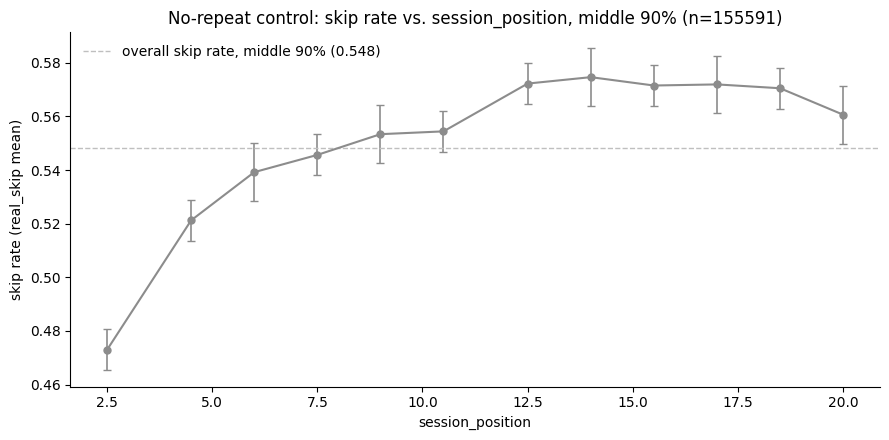

In [11]:
lo_p, hi_p = control["session_position"].quantile([0.05, 0.95])
control_mid = control[(control["session_position"] >= lo_p) & (control["session_position"] <= hi_p)].copy()
control_mid["position_bin"] = pd.qcut(control_mid["session_position"], q=NUM_BINS, duplicates="drop")

binned_control_mid = control_mid.groupby("position_bin", observed=True).agg(
    bin_mean_position=("session_position", "mean"),
    skip_rate=("real_skip", "mean"),
    n=("real_skip", "size"),
).reset_index()
binned_control_mid["ci95"] = 1.96 * np.sqrt(
    binned_control_mid["skip_rate"] * (1 - binned_control_mid["skip_rate"]) / binned_control_mid["n"])

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.errorbar(binned_control_mid["bin_mean_position"], binned_control_mid["skip_rate"],
            yerr=binned_control_mid["ci95"], fmt="o-", color="0.55", ecolor="0.55",
            elinewidth=1.2, capsize=3, markersize=5, linewidth=1.5)
ax.axhline(control_mid["real_skip"].mean(), color="0.75", linewidth=1, linestyle="--",
           label=f"overall skip rate, middle 90% ({control_mid['real_skip'].mean():.3f})")
ax.set_xlabel("session_position")
ax.set_ylabel("skip rate (real_skip mean)")
ax.set_title(f"No-repeat control: skip rate vs. session_position, middle 90% (n={len(control_mid)})")
ax.legend(frameon=False, loc="best")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Two-pass comparison: real evaluation values for BOTH conditions

Mark pointed out that "no evaluation for no-repeat sessions" was a limitation of the
single-pass driver, not the algorithm itself -- `evaluate_a4` just requires a song to already
have its own chunk, which running the session twice (pass 1 to populate memory, pass 2 to
evaluate, keeping only pass 2) satisfies for every trial, on both session types. See
`run_real_session_two_pass`'s docstring for the full method and the pass-2-first-row exclusion
(the same forced-evaluation==0 artifact as before, now landing at a fixed point for both
conditions rather than only affecting the qualifying side).

This finally allows a real, direct comparison: the SAME evaluation-vs-real_skip analysis, on
sessions that actually had a natural repeat (`qualifying`) vs. sessions that never did and only
got a "probed" second exposure via the replay (`no_repeat`).

In [12]:
TWO_PASS_QUALIFYING_PATH = "../results/data/real_sessions_two_pass_qualifying_sample.csv"
TWO_PASS_NO_REPEAT_PATH = "../results/data/real_sessions_two_pass_no_repeat_sample.csv"

tp_qualifying = pd.read_csv(TWO_PASS_QUALIFYING_PATH).dropna(subset=["real_skip", "evaluation"])
tp_no_repeat = pd.read_csv(TWO_PASS_NO_REPEAT_PATH).dropna(subset=["real_skip", "evaluation"])

for name, frame in [("qualifying (real repeat)", tp_qualifying), ("no_repeat (probed via pass 2)", tp_no_repeat)]:
    r = frame["real_skip"].corr(frame["evaluation"])
    sr = frame["evaluation"].rank().corr(frame["real_skip"].rank())
    print(f"{name}: n={len(frame)}, sessions={frame['session_id'].nunique()}, "
          f"Pearson r={r:.4f}, Spearman r={sr:.4f}")

qualifying (real repeat): n=27009, sessions=1444, Pearson r=-0.0183, Spearman r=-0.0195
no_repeat (probed via pass 2): n=28073, sessions=1500, Pearson r=-0.0012, Spearman r=0.0061


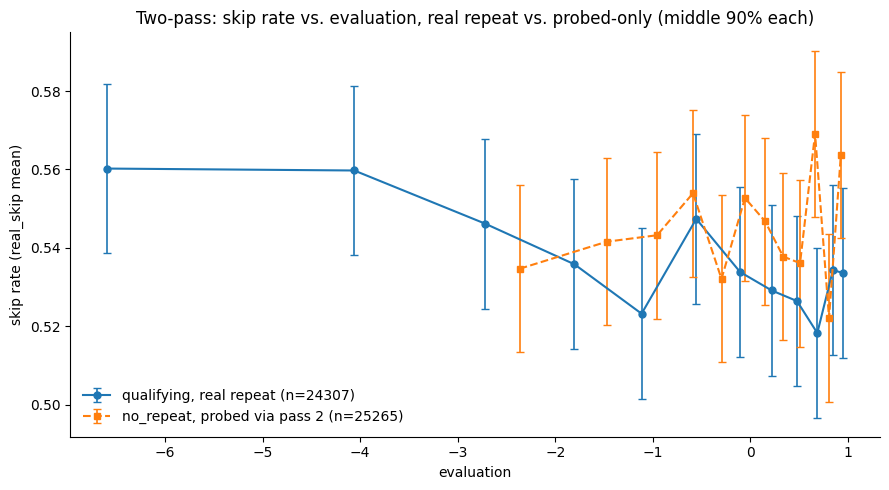

In [13]:
def binned_skip_rate(frame, value_col, num_bins=NUM_BINS):
    frame = frame.copy()
    frame["_bin"] = pd.qcut(frame[value_col], q=num_bins, duplicates="drop")
    g = frame.groupby("_bin", observed=True).agg(
        bin_mean=(value_col, "mean"), skip_rate=("real_skip", "mean"),
        n=("real_skip", "size")).reset_index()
    g["ci95"] = 1.96 * np.sqrt(g["skip_rate"] * (1 - g["skip_rate"]) / g["n"])
    return g

# trim both to their own middle 90% (same treatment as the single-pass zoomed view earlier)
def middle_90(frame, value_col):
    lo, hi = frame[value_col].quantile([0.05, 0.95])
    return frame[(frame[value_col] >= lo) & (frame[value_col] <= hi)]

tp_qualifying_mid = middle_90(tp_qualifying, "evaluation")
tp_no_repeat_mid = middle_90(tp_no_repeat, "evaluation")

binned_qualifying = binned_skip_rate(tp_qualifying_mid, "evaluation")
binned_no_repeat = binned_skip_rate(tp_no_repeat_mid, "evaluation")

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(binned_qualifying["bin_mean"], binned_qualifying["skip_rate"],
            yerr=binned_qualifying["ci95"], fmt="o-", color="tab:blue", ecolor="tab:blue",
            elinewidth=1.2, capsize=3, markersize=5, linewidth=1.5,
            label=f"qualifying, real repeat (n={len(tp_qualifying_mid)})")
ax.errorbar(binned_no_repeat["bin_mean"], binned_no_repeat["skip_rate"],
            yerr=binned_no_repeat["ci95"], fmt="s--", color="tab:orange", ecolor="tab:orange",
            elinewidth=1.2, capsize=3, markersize=5, linewidth=1.5,
            label=f"no_repeat, probed via pass 2 (n={len(tp_no_repeat_mid)})")

ax.set_xlabel("evaluation")
ax.set_ylabel("skip rate (real_skip mean)")
ax.set_title("Two-pass: skip rate vs. evaluation, real repeat vs. probed-only (middle 90% each)")
ax.legend(frameon=False, loc="best")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Burn-in comparison (replaces the two-pass technique)

Mark judged two-pass "not a good design" and specified a proper burn-in procedure instead
(2026-08-28) -- see `run_real_session_with_burn_in`'s docstring for the full method (3x
permuted exposure to the session's own songs, then 100 exposures to a fixed 20-song fake
corpus, THEN the real session data once). Burn-in runs real `evaluate_a4` throughout, so the
running average matures well before the real pass -- confirmed empirically: zero exact-0.0
evaluations anywhere in these results, unlike every earlier version.

In [14]:
BURN_IN_QUALIFYING_PATH = "../results/data/real_sessions_burn_in_qualifying_sample.csv"
BURN_IN_NO_REPEAT_PATH = "../results/data/real_sessions_burn_in_no_repeat_sample.csv"

bi_qualifying = pd.read_csv(BURN_IN_QUALIFYING_PATH).dropna(subset=["real_skip", "evaluation"])
bi_no_repeat = pd.read_csv(BURN_IN_NO_REPEAT_PATH).dropna(subset=["real_skip", "evaluation"])

for name, frame in [("qualifying (real repeat)", bi_qualifying), ("no_repeat (burn-in only)", bi_no_repeat)]:
    r = frame["real_skip"].corr(frame["evaluation"])
    sr = frame["evaluation"].rank().corr(frame["real_skip"].rank())
    print(f"{name}: n={len(frame)}, sessions={frame['session_id'].nunique()}, "
          f"Pearson r={r:.4f}, Spearman r={sr:.4f}")
    print(frame["evaluation"].describe())
    print()

qualifying (real repeat): n=28416, sessions=1444, Pearson r=-0.0051, Spearman r=-0.0055
count    28416.000000
mean        -3.180463
std          3.827087
min        -34.440337
25%         -5.300991
50%         -2.534168
75%          0.176197
max          1.000000
Name: evaluation, dtype: float64

no_repeat (burn-in only): n=29520, sessions=1500, Pearson r=0.0071, Spearman r=0.0051
count    29520.000000
mean        -4.116082
std          3.111254
min        -37.302698
25%         -5.707093
50%         -3.607065
75%         -1.926664
max          1.000000
Name: evaluation, dtype: float64



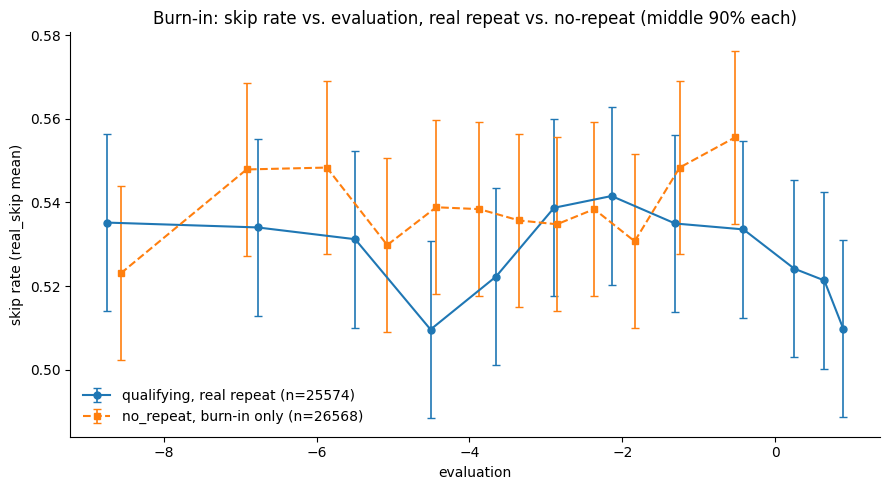

In [15]:
bi_qualifying_mid = middle_90(bi_qualifying, "evaluation")
bi_no_repeat_mid = middle_90(bi_no_repeat, "evaluation")

binned_bi_qualifying = binned_skip_rate(bi_qualifying_mid, "evaluation")
binned_bi_no_repeat = binned_skip_rate(bi_no_repeat_mid, "evaluation")

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(binned_bi_qualifying["bin_mean"], binned_bi_qualifying["skip_rate"],
            yerr=binned_bi_qualifying["ci95"], fmt="o-", color="tab:blue", ecolor="tab:blue",
            elinewidth=1.2, capsize=3, markersize=5, linewidth=1.5,
            label=f"qualifying, real repeat (n={len(bi_qualifying_mid)})")
ax.errorbar(binned_bi_no_repeat["bin_mean"], binned_bi_no_repeat["skip_rate"],
            yerr=binned_bi_no_repeat["ci95"], fmt="s--", color="tab:orange", ecolor="tab:orange",
            elinewidth=1.2, capsize=3, markersize=5, linewidth=1.5,
            label=f"no_repeat, burn-in only (n={len(bi_no_repeat_mid)})")

ax.set_xlabel("evaluation")
ax.set_ylabel("skip rate (real_skip mean)")
ax.set_title("Burn-in: skip rate vs. evaluation, real repeat vs. no-repeat (middle 90% each)")
ax.legend(frameon=False, loc="best")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Phase 1 ablation: removing the fake-corpus exposures

Mark's next step to resolve the open question above: rerun burn-in with `phase1=False` (skip
the 100 fake-corpus exposures entirely, keep only phase 0's 3x permuted exposure to the
session's own songs) and see whether the signal returns.

In [16]:
NO_PHASE1_QUALIFYING_PATH = "../results/data/real_sessions_burn_in_qualifying_no_phase1_sample.csv"
NO_PHASE1_NO_REPEAT_PATH = "../results/data/real_sessions_burn_in_no_repeat_no_phase1_sample.csv"

np1_qualifying = pd.read_csv(NO_PHASE1_QUALIFYING_PATH).dropna(subset=["real_skip", "evaluation"])
np1_no_repeat = pd.read_csv(NO_PHASE1_NO_REPEAT_PATH).dropna(subset=["real_skip", "evaluation"])

for name, frame in [("qualifying, no phase1", np1_qualifying), ("no_repeat, no phase1", np1_no_repeat)]:
    r = frame["real_skip"].corr(frame["evaluation"])
    sr = frame["evaluation"].rank().corr(frame["real_skip"].rank())
    print(f"{name}: n={len(frame)}, sessions={frame['session_id'].nunique()}, "
          f"Pearson r={r:.4f}, Spearman r={sr:.4f}")
    print(frame["evaluation"].describe())
    print()

qualifying, no phase1: n=28416, sessions=1444, Pearson r=-0.0105, Spearman r=-0.0196
count    28416.000000
mean        -0.396665
std          2.009426
min        -50.021654
25%         -0.861343
50%          0.287016
75%          0.817831
max          1.000000
Name: evaluation, dtype: float64



no_repeat, no phase1: n=29520, sessions=1500, Pearson r=-0.0082, Spearman r=-0.0120
count    29520.000000
mean        -0.311503
std          1.474818
min        -23.326833
25%         -0.847360
50%          0.139350
75%          0.730932
max          1.000000
Name: evaluation, dtype: float64



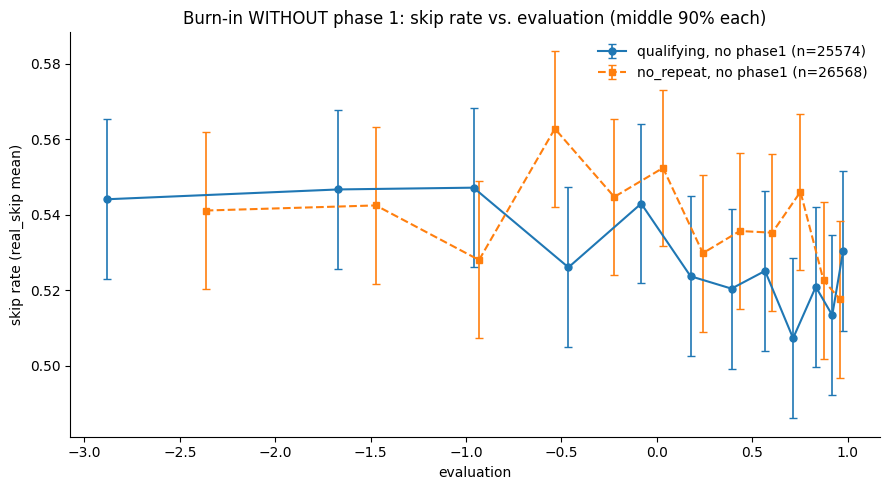

In [17]:
np1_qualifying_mid = middle_90(np1_qualifying, "evaluation")
np1_no_repeat_mid = middle_90(np1_no_repeat, "evaluation")

binned_np1_qualifying = binned_skip_rate(np1_qualifying_mid, "evaluation")
binned_np1_no_repeat = binned_skip_rate(np1_no_repeat_mid, "evaluation")

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(binned_np1_qualifying["bin_mean"], binned_np1_qualifying["skip_rate"],
            yerr=binned_np1_qualifying["ci95"], fmt="o-", color="tab:blue", ecolor="tab:blue",
            elinewidth=1.2, capsize=3, markersize=5, linewidth=1.5,
            label=f"qualifying, no phase1 (n={len(np1_qualifying_mid)})")
ax.errorbar(binned_np1_no_repeat["bin_mean"], binned_np1_no_repeat["skip_rate"],
            yerr=binned_np1_no_repeat["ci95"], fmt="s--", color="tab:orange", ecolor="tab:orange",
            elinewidth=1.2, capsize=3, markersize=5, linewidth=1.5,
            label=f"no_repeat, no phase1 (n={len(np1_no_repeat_mid)})")

ax.set_xlabel("evaluation")
ax.set_ylabel("skip rate (real_skip mean)")
ax.set_title("Burn-in WITHOUT phase 1: skip rate vs. evaluation (middle 90% each)")
ax.legend(frameon=False, loc="best")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Phase 0 repeat-count ablation: just 1 repeat, no phase 1

Further ablation: `phase0_repeats=1` (a single permutation -- every song exposed exactly once,
no repeat at all during burn-in) with `phase1=False`. Confirmed empirically beforehand: with no
repeat anywhere in burn-in, the model's very first-ever `evaluate_a4` call happens on the real
pass's first row, so the forced-evaluation==0 artifact resurfaces exactly like the old
single-pass approach (1 exact-zero row per session, confirmed) -- `drop_first_evaluable_trial`
is applied here before computing anything, unlike the phase0_repeats=3 results above.

In [18]:
PHASE0X1_QUALIFYING_PATH = "../results/data/real_sessions_burn_in_qualifying_no_phase1_phase0x1_sample.csv"
PHASE0X1_NO_REPEAT_PATH = "../results/data/real_sessions_burn_in_no_repeat_no_phase1_phase0x1_sample.csv"

p0x1_qualifying = drop_first_evaluable_trial(pd.read_csv(PHASE0X1_QUALIFYING_PATH)).dropna(subset=["real_skip", "evaluation"])
p0x1_no_repeat = drop_first_evaluable_trial(pd.read_csv(PHASE0X1_NO_REPEAT_PATH)).dropna(subset=["real_skip", "evaluation"])

for name, frame in [("qualifying, phase0x1 no phase1", p0x1_qualifying), ("no_repeat, phase0x1 no phase1", p0x1_no_repeat)]:
    r = frame["real_skip"].corr(frame["evaluation"])
    sr = frame["evaluation"].rank().corr(frame["real_skip"].rank())
    print(f"{name}: n={len(frame)}, sessions={frame['session_id'].nunique()}, "
          f"Pearson r={r:.4f}, Spearman r={sr:.4f}")

qualifying, phase0x1 no phase1: n=27009, sessions=1444, Pearson r=0.0023, Spearman r=-0.0076
no_repeat, phase0x1 no phase1: n=28073, sessions=1500, Pearson r=0.0040, Spearman r=0.0020


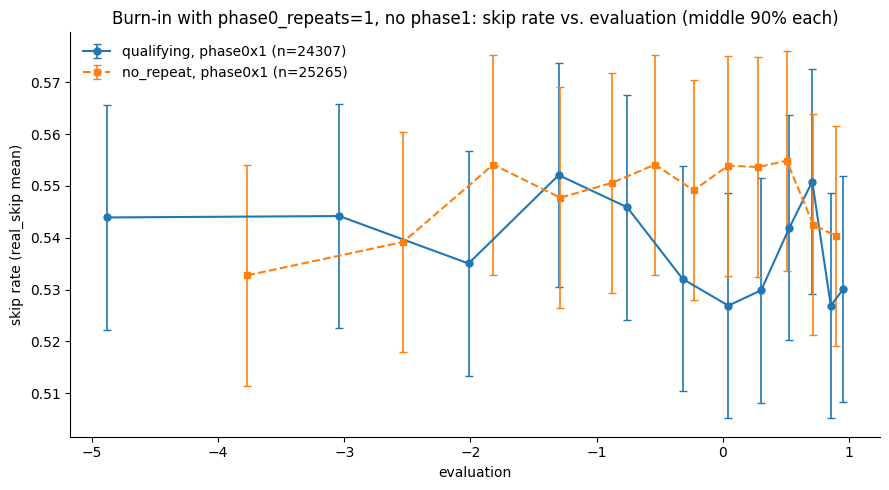

In [19]:
p0x1_qualifying_mid = middle_90(p0x1_qualifying, "evaluation")
p0x1_no_repeat_mid = middle_90(p0x1_no_repeat, "evaluation")

binned_p0x1_qualifying = binned_skip_rate(p0x1_qualifying_mid, "evaluation")
binned_p0x1_no_repeat = binned_skip_rate(p0x1_no_repeat_mid, "evaluation")

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(binned_p0x1_qualifying["bin_mean"], binned_p0x1_qualifying["skip_rate"],
            yerr=binned_p0x1_qualifying["ci95"], fmt="o-", color="tab:blue", ecolor="tab:blue",
            elinewidth=1.2, capsize=3, markersize=5, linewidth=1.5,
            label=f"qualifying, phase0x1 (n={len(p0x1_qualifying_mid)})")
ax.errorbar(binned_p0x1_no_repeat["bin_mean"], binned_p0x1_no_repeat["skip_rate"],
            yerr=binned_p0x1_no_repeat["ci95"], fmt="s--", color="tab:orange", ecolor="tab:orange",
            elinewidth=1.2, capsize=3, markersize=5, linewidth=1.5,
            label=f"no_repeat, phase0x1 (n={len(p0x1_no_repeat_mid)})")

ax.set_xlabel("evaluation")
ax.set_ylabel("skip rate (real_skip mean)")
ax.set_title("Burn-in with phase0_repeats=1, no phase1: skip rate vs. evaluation (middle 90% each)")
ax.legend(frameon=False, loc="best")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()